# The error(dz, q) tables of the architecture grid (Block C, C4)

This notebook **computes nothing**. It loads what `aggregate_grid.py`,
`tables.py` and `plot_tables.py` wrote and displays it. Every number below is
read from `results/`; the argument that goes with them is in
[README.md](README.md), section C4.

The subject is the 720-run grid of C3 — width x depth x q x {physics loss, data
twin} x 3 seeds, trained on the magnet-to-magnet set of
`../Magnet_tracks_dataset` — read as a surface over step length and stage
count, against the exact scheme of `../Exact_scheme_table` and the straight
line.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 250)
RESULTS, FIGURES = "results", "figures"

STRATA = ["0.05-0.2 mm", "0.5-2 mm", "5-20 mm", "50-200 mm", "500-2000 mm",
          "full crossing"]
cells = pd.read_csv(os.path.join(RESULTS, "table_cells.csv"))
cells["stratum"] = pd.Categorical(cells["stratum"], STRATA + ["all"],
                                  ordered=True)
T = cells[(cells.split == "test") & (cells.direction == "all")]
print(len(cells), "cells;", len(T), "on the test split, both directions pooled")
print("architectures:", sorted(T.arch.unique()))

10080 cells; 1680 on the test split, both directions pooled
architectures: ['2x128', '2x256', '2x32', '2x64', '4x128', '4x256', '4x32', '4x64', '8x128', '8x256', '8x32', '8x64']


## What had landed

`results/pending_cells.csv` is the list of grid points with no record on disk.
A cell built from fewer than three seeds carries `pending = True`.

In [2]:
P = pd.read_csv(os.path.join(RESULTS, "pending_cells.csv"))
print("%d of 720 grid points missing" % len(P))
display(P)
print("cells built from fewer than 3 seeds:",
      int(T[T.pending].groupby(["arch", "mode", "q"]).ngroups))

5 of 720 grid points missing


,tag,width,depth,q,mode,seed,cell,seeds_present_in_cell
0,w256_d8_q06_data_s2,256,8,6,data,2,8x256 data q=6,2
1,w256_d8_q08_data_s0,256,8,8,data,0,8x256 data q=8,2
2,w256_d8_q12_data_s2,256,8,12,data,2,8x256 data q=12,2
3,w256_d8_q18_data_s1,256,8,18,data,1,8x256 data q=18,2
4,w256_d8_q20_data_s0,256,8,20,data,0,8x256 data q=20,2


cells built from fewer than 3 seeds: 5


## C4.1 The tables

`results/table_<D>x<W>.csv` is the display table: rows q, columns the six
strata, `median [min-max]` over the seeds for each arm, then the exact scheme
at every q and the straight line.

In [3]:
for arch in ("4x64", "8x256"):
    print("=" * 30, arch)
    display(pd.read_csv(os.path.join(RESULTS, "table_%s.csv" % arch)))

============================== 4x64


,row,arm,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
0,q=2,physics,1.75e-05 [1.47e-05-2.51e-05],0.0018 [0.00149-0.00276],0.186 [0.14-0.273],13.5 [12.4-20.7],312 [304-318],9.92e+03 [9.74e+03-1.03e+04]
1,q=2,twin,1.55e-06 [1.4e-06-1.78e-06],0.000141 [0.000133-0.000175],0.0172 [0.0164-0.0199],2.16 [2.12-3.03],323 [314-405],3.57e+03 [2.87e+03-4.02e+03]
2,q=4,physics,1.18e-05 [9.43e-06-1.21e-05],0.00124 [0.00098-0.00125],0.126 [0.105-0.127],10.2 [9.14-11.1],272 [259-272],3.58e+03 [3.53e+03-3.72e+03]
3,q=4,twin,1.67e-06 [1.31e-06-3.25e-06],0.00015 [0.00013-0.000216],0.0168 [0.015-0.0226],2.18 [1.85-2.46],367 [260-487],3.86e+03 [3.21e+03-6.33e+03]
4,q=6,physics,7.86e-06 [6.16e-06-2.45e-05],0.000802 [0.000655-0.00261],0.0841 [0.0652-0.257],8.18 [8.04-16.2],295 [269-299],755 [737-785]
5,q=6,twin,2.43e-06 [1.16e-06-3.02e-06],0.000221 [0.00011-0.000252],0.0237 [0.0114-0.0277],2.84 [1.76-3.47],481 [274-575],5.78e+03 [3.72e+03-7.25e+03]
6,q=8,physics,2.35e-05 [1.44e-05-2.48e-05],0.00246 [0.00153-0.00267],0.245 [0.154-0.27],15.1 [13.2-16.3],276 [275-310],776 [733-807]
7,q=8,twin,1.77e-06 [1.42e-06-4.11e-06],0.000182 [0.000167-0.000344],0.0225 [0.0172-0.0309],2.78 [2.21-3.47],392 [384-927],4.77e+03 [4.57e+03-8.17e+03]
8,q=10,physics,1.85e-05 [8.38e-06-3.02e-05],0.00193 [0.000855-0.00331],0.2 [0.0986-0.325],15.9 [11.3-26.7],290 [261-298],736 [706-749]
9,q=10,twin,2.11e-06 [2.06e-06-2.22e-06],0.000203 [0.000178-0.000254],0.0193 [0.0186-0.0263],2.52 [2.2-2.55],409 [343-579],5.42e+03 [3.93e+03-6.17e+03]


============================== 8x256


,row,arm,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
0,q=2,physics,1.73e-05 [1.56e-05-4.07e-05],0.00164 [0.00156-0.00418],0.17 [0.159-0.416],10 [9.94-19.7],282 [278-299],9.68e+03 [9.55e+03-9.93e+03]
1,q=2,twin,3.11e-06 [2.14e-06-3.5e-06],0.000272 [0.000217-0.000276],0.0271 [0.0227-0.0304],3.17 [3.11-3.51],498 [495-738],4.98e+03 [4.44e+03-6.33e+03]
2,q=4,physics,3.71e-05 [3.11e-05-3.8e-05],0.0039 [0.00331-0.004],0.377 [0.311-0.385],20.6 [19.3-24.9],241 [240-261],3.53e+03 [3.51e+03-3.57e+03]
3,q=4,twin,3.89e-06 [9.73e-07-4.81e-06],0.000325 [5.21e-05-0.000332],0.031 [0.00684-0.0337],3.5 [0.928-4.3],743 [138-783],5.78e+03 [1.06e+03-7.34e+03]
4,q=6,physics,2.73e-05 [1.09e-05-4.46e-05],0.00282 [0.0012-0.00456],0.267 [0.113-0.444],12.5 [7.72-20.5],261 [242-271],769 [709-770]
5,q=6,twin,2.78e-06 [2.6e-06-2.96e-06] (2/3 seeds),0.000231 [0.000228-0.000235] (2/3 seeds),0.0253 [0.0241-0.0265] (2/3 seeds),2.66 [2.6-2.71] (2/3 seeds),426 [415-437] (2/3 seeds),4.59e+03 [4.48e+03-4.69e+03] (2/3 seeds)
6,q=8,physics,3.05e-05 [2.63e-05-4.16e-05],0.00304 [0.00281-0.00442],0.299 [0.264-0.427],16.2 [12.8-25.1],229 [215-272],660 [632-669]
7,q=8,twin,4.2e-06 [4.16e-06-4.25e-06] (2/3 seeds),0.000336 [0.000282-0.000389] (2/3 seeds),0.0312 [0.03-0.0323] (2/3 seeds),4.01 [3.57-4.46] (2/3 seeds),860 [806-913] (2/3 seeds),6.43e+03 [6.39e+03-6.47e+03] (2/3 seeds)
8,q=10,physics,2.09e-05 [1.55e-05-3.86e-05],0.00218 [0.00161-0.00399],0.216 [0.161-0.388],12.4 [12-17.7],228 [227-259],747 [705-759]
9,q=10,twin,2.92e-06 [2.46e-06-3.57e-06],0.000258 [0.000197-0.000303],0.0257 [0.0212-0.0287],3.06 [2.62-3.13],572 [475-607],5.22e+03 [4.36e+03-5.35e+03]


The same numbers as a pivot, so the trend down each column is easy to read.

In [4]:
def grid_of(arch, mode):
    g = (T[(T.arch == arch) & (T["mode"] == mode)]
         .pivot(index="q", columns="stratum", values="median_um")
         .reindex(columns=STRATA))
    g.loc["straight line"] = [T[T.stratum == s].straight_um.median()
                              for s in STRATA]
    return g

for arch in ("4x64", "8x256"):
    for mode in ("physics", "data"):
        print(arch, mode)
        display(grid_of(arch, mode).style.format("{:.4g}"))

4x64 physics


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.749e-05,0.001795,0.1855,13.52,312.4,9919
4,1.182e-05,0.001236,0.1257,10.23,271.5,3582
6,7.863e-06,0.0008021,0.0841,8.176,294.7,754.6
8,2.345e-05,0.002458,0.2454,15.1,276.3,775.7
10,1.855e-05,0.001935,0.2002,15.91,289.9,736.5
12,1.912e-05,0.001913,0.1926,15.14,302.7,726
14,2.066e-05,0.002157,0.2202,15.06,330,813.8
16,9.631e-06,0.001047,0.1076,9.422,288.2,766
18,1.813e-05,0.001852,0.1945,16.79,284.5,769.5


4x64 data


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.55e-06,0.0001414,0.01717,2.162,322.6,3565
4,1.669e-06,0.0001501,0.01676,2.179,367.2,3857
6,2.434e-06,0.0002213,0.02368,2.845,480.8,5781
8,1.765e-06,0.0001816,0.02248,2.782,392.3,4767
10,2.108e-06,0.0002035,0.0193,2.521,408.8,5419
12,3.111e-06,0.000281,0.02859,2.995,668.4,5852
14,3.053e-06,0.0002094,0.02145,2.436,442.3,6203
16,1.831e-06,0.0001984,0.02104,2.473,414.6,4972
18,1.978e-06,0.0002185,0.01988,2.221,387.4,4828


8x256 physics


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.725e-05,0.001642,0.1704,10.02,282.3,9676
4,3.709e-05,0.003899,0.3767,20.61,240.6,3533
6,2.731e-05,0.002817,0.2668,12.47,261.5,769.4
8,3.045e-05,0.003036,0.2995,16.24,229.4,659.6
10,2.087e-05,0.002176,0.2159,12.42,227.8,747.2
12,2.498e-05,0.002708,0.2579,17.1,244.4,645.3
14,2.024e-05,0.002238,0.2117,14.87,248,621.3
16,3.563e-05,0.003691,0.3546,17.6,225,669.6
18,2.812e-05,0.002923,0.311,21.84,229.8,592.9


8x256 data


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,3.106e-06,0.0002721,0.02709,3.173,497.7,4978
4,3.894e-06,0.0003249,0.03104,3.496,743.1,5782
6,2.779e-06,0.0002312,0.0253,2.659,426,4585
8,4.201e-06,0.0003359,0.03117,4.014,860,6433
10,2.919e-06,0.0002579,0.02567,3.064,571.8,5216
12,4.391e-06,0.0002845,0.02889,3.558,830.7,6090
14,2.731e-06,0.0002347,0.02192,2.473,444.2,5111
16,3.621e-06,0.0002795,0.02765,2.826,578.9,5960
18,3.389e-06,0.0002627,0.02382,2.595,505.8,4846


### The two reference rows

The exact q-stage scheme and the straight line, from `../Exact_scheme_table`.

In [5]:
S = pd.read_csv(os.path.join("..", "Exact_scheme_table", "results",
                             "scheme_table.csv"))
L = pd.read_csv(os.path.join("..", "Exact_scheme_table", "results",
                             "straight_line_table.csv"))
ref = (S[S.direction == "both"].pivot(index="q", columns="stratum",
                                      values="endpoint_med_um")
       .reindex(columns=STRATA))
ref.loc["straight line"] = (L[L.direction == "both"]
                            .set_index("stratum")["endpoint_med_um"]
                            .reindex(STRATA).values)
display(ref.style.format("{:.4g}"))
print("the fine reference's own floor: 5e-5 um over a whole crossing "
      "(../Fine_reference C1.4), far lower per short step")

stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.421e-11,2.345e-10,3.183e-09,0.003211,12.79,9256
4,1.421e-11,2.349e-10,3.07e-09,0.0007494,1.218,3617
6,1.421e-11,2.345e-10,3.07e-09,0.0003483,0.8252,232.6
8,1.421e-11,2.345e-10,3.048e-09,0.0002007,0.6958,32.63
10,1.421e-11,2.309e-10,3.038e-09,0.000137,0.5044,32.49
12,1.421e-11,2.345e-10,3.02e-09,9.708e-05,0.3964,41.5
14,1.421e-11,2.345e-10,3.038e-09,6.498e-05,0.3038,20.36
16,1.421e-11,2.345e-10,3.013e-09,5.335e-05,0.2189,36.13
18,1.421e-11,2.274e-10,3.002e-09,4.208e-05,0.1671,38.62


the fine reference's own floor: 5e-5 um over a whole crossing (../Fine_reference C1.4), far lower per short step


## C4.2 The figures

heatmap_4x64.png


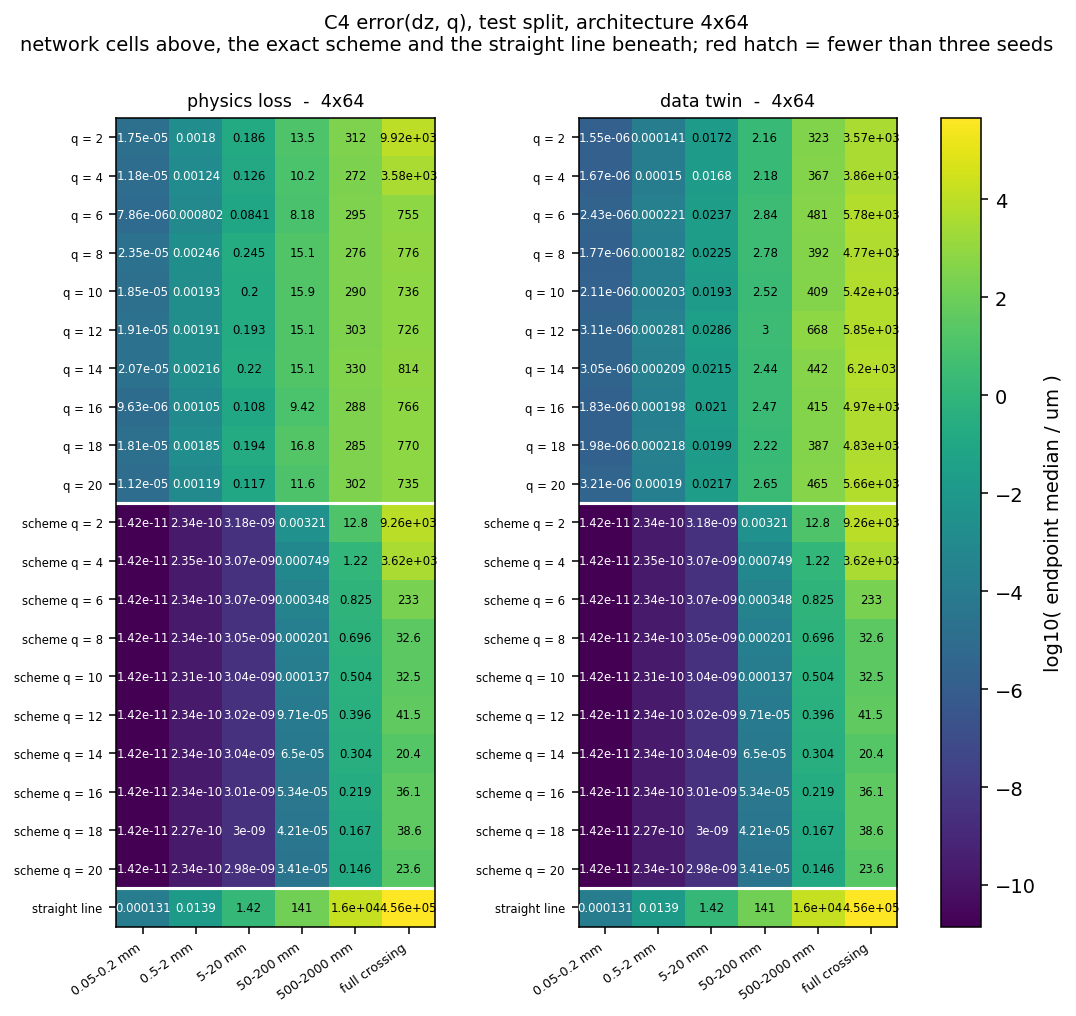

heatmap_8x256.png


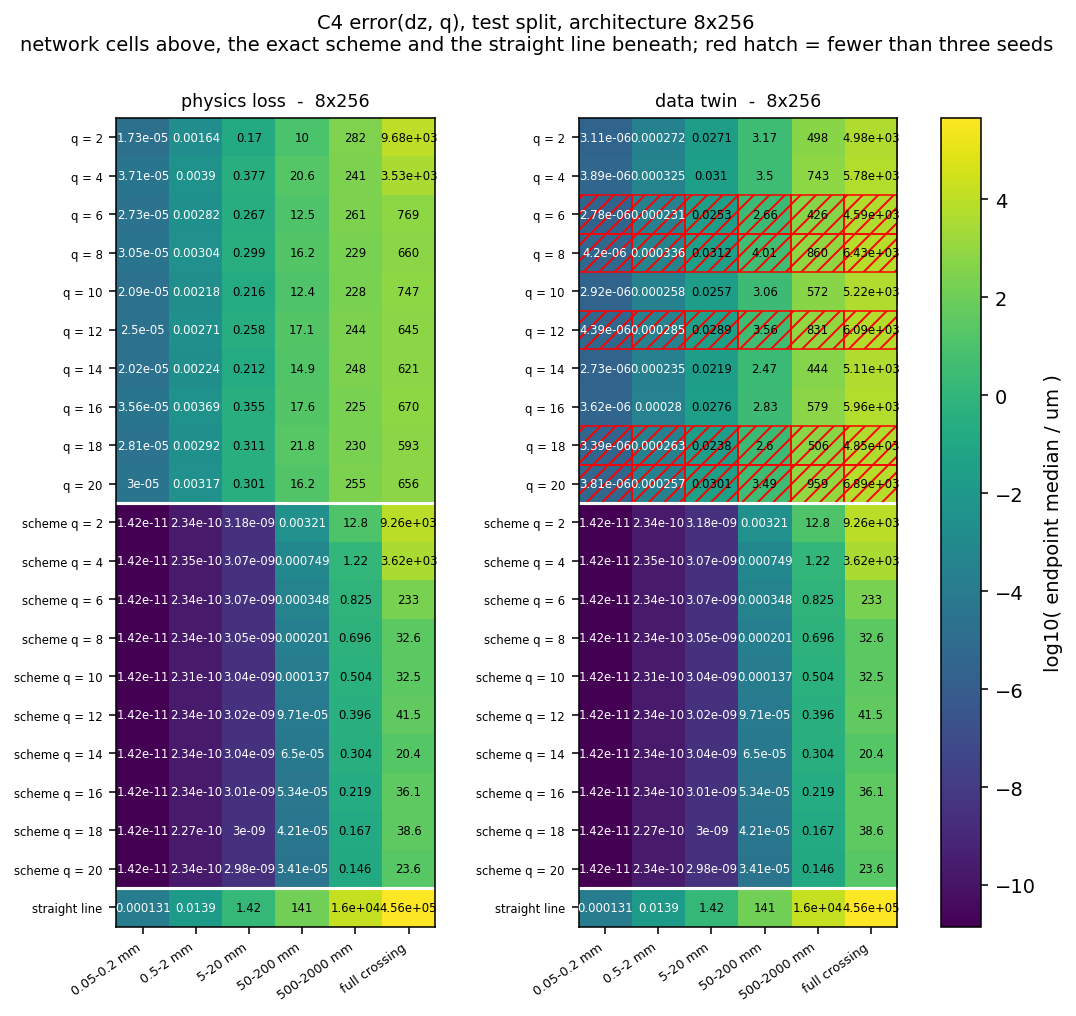

error_vs_dz.png


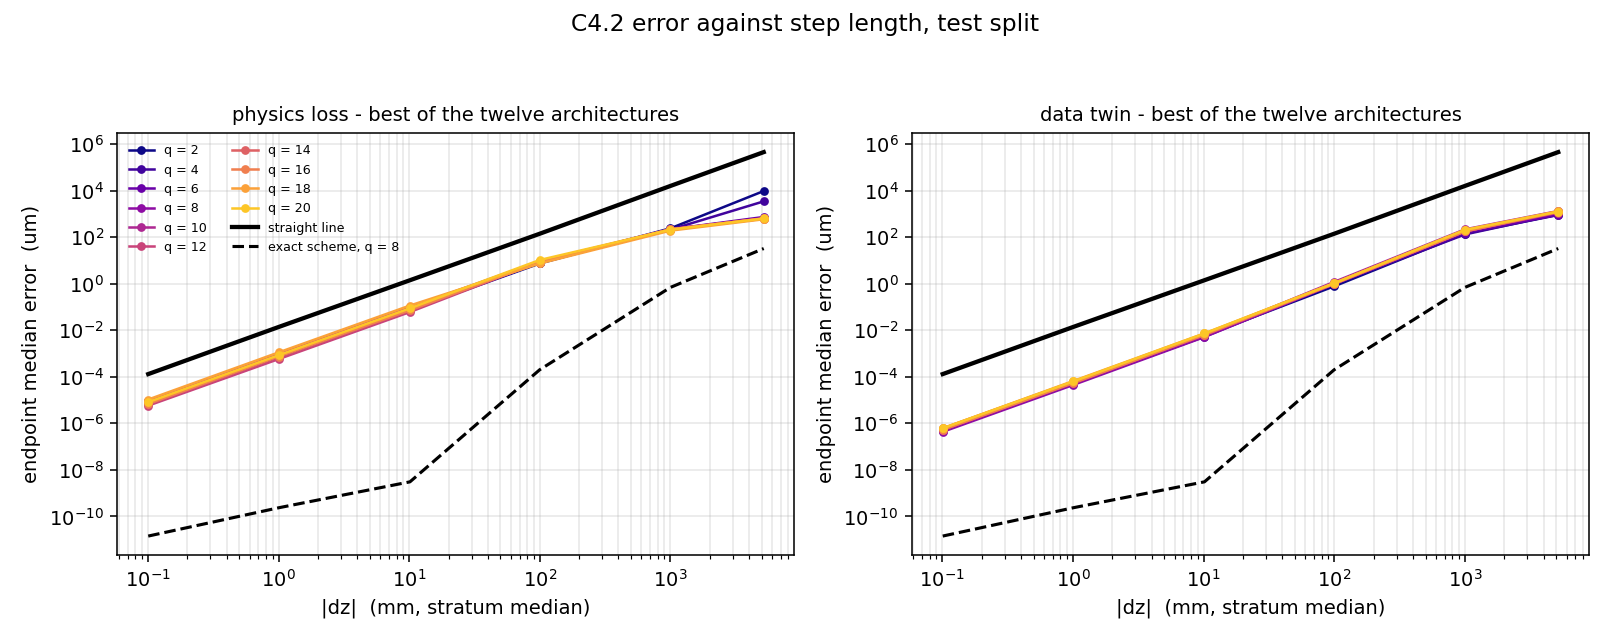

error_vs_q.png


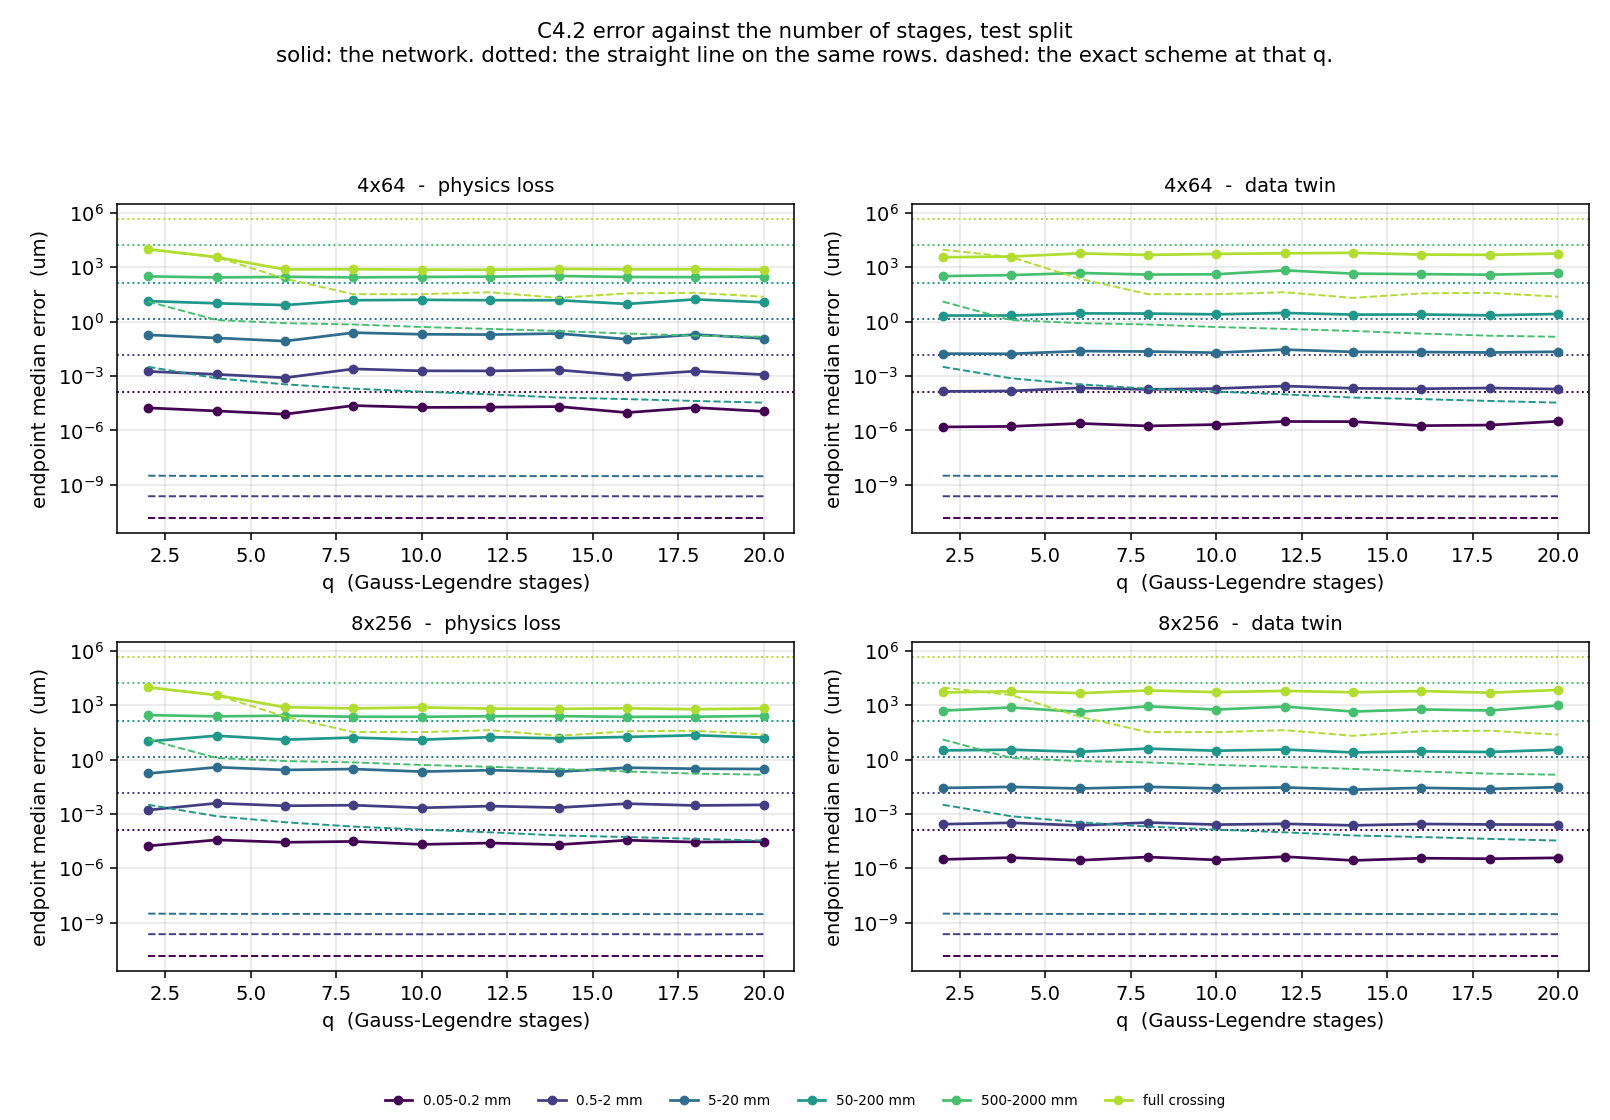

physics_over_twin.png


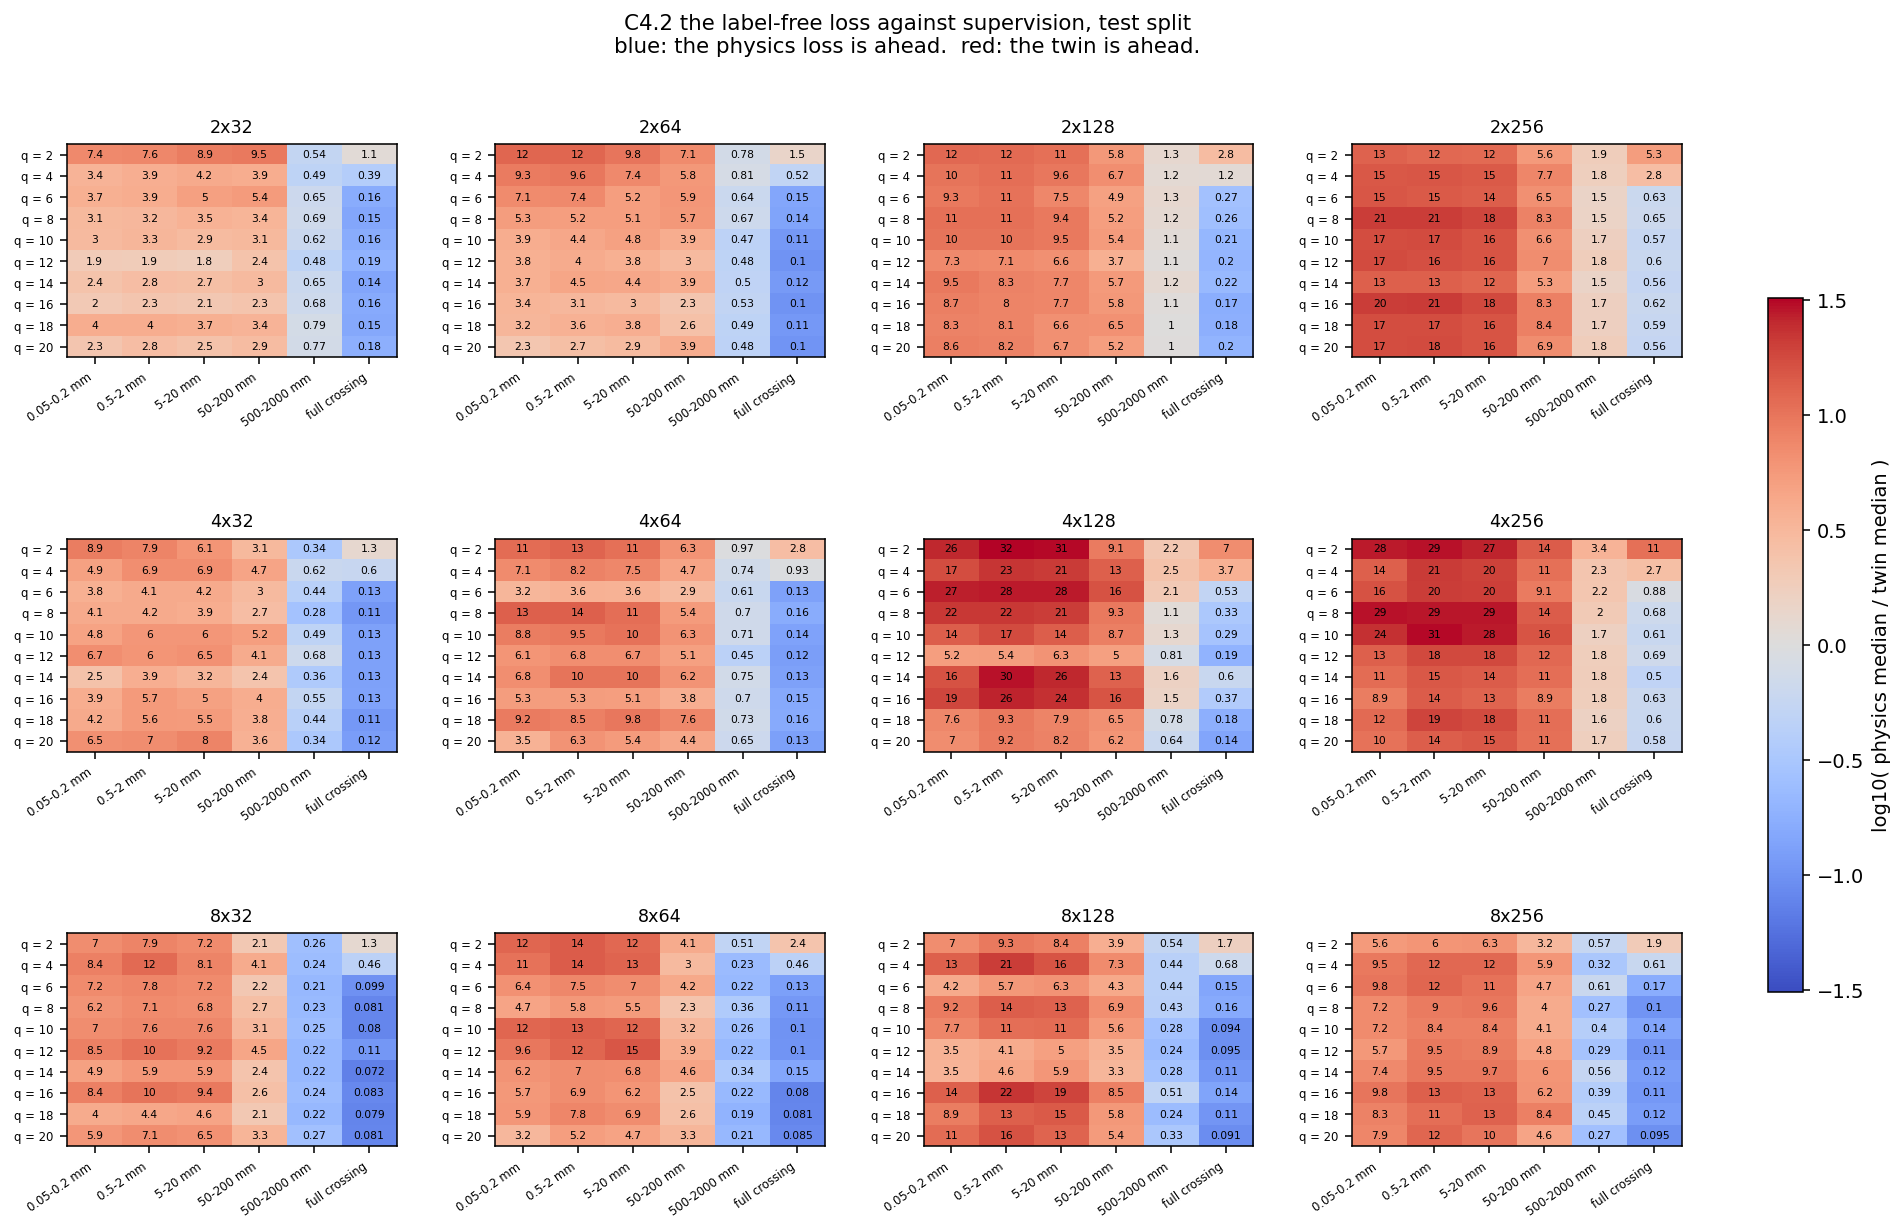

cost_vs_error.png


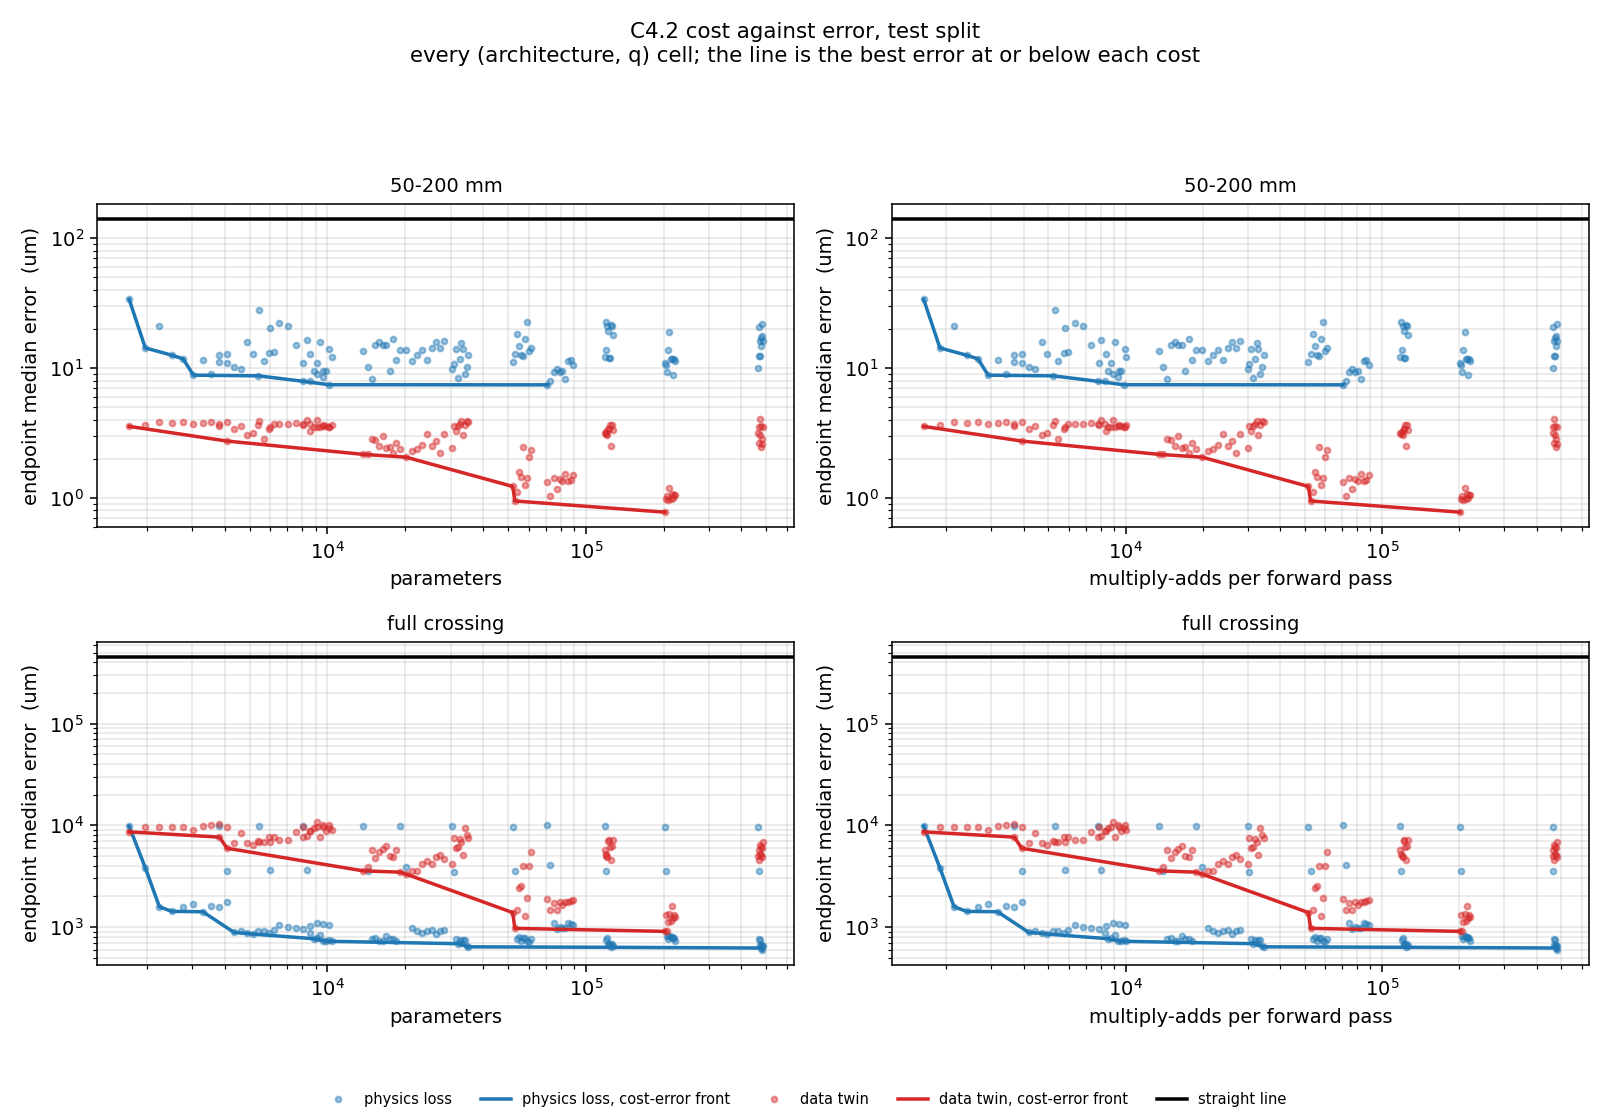

best_architecture_per_cell.png


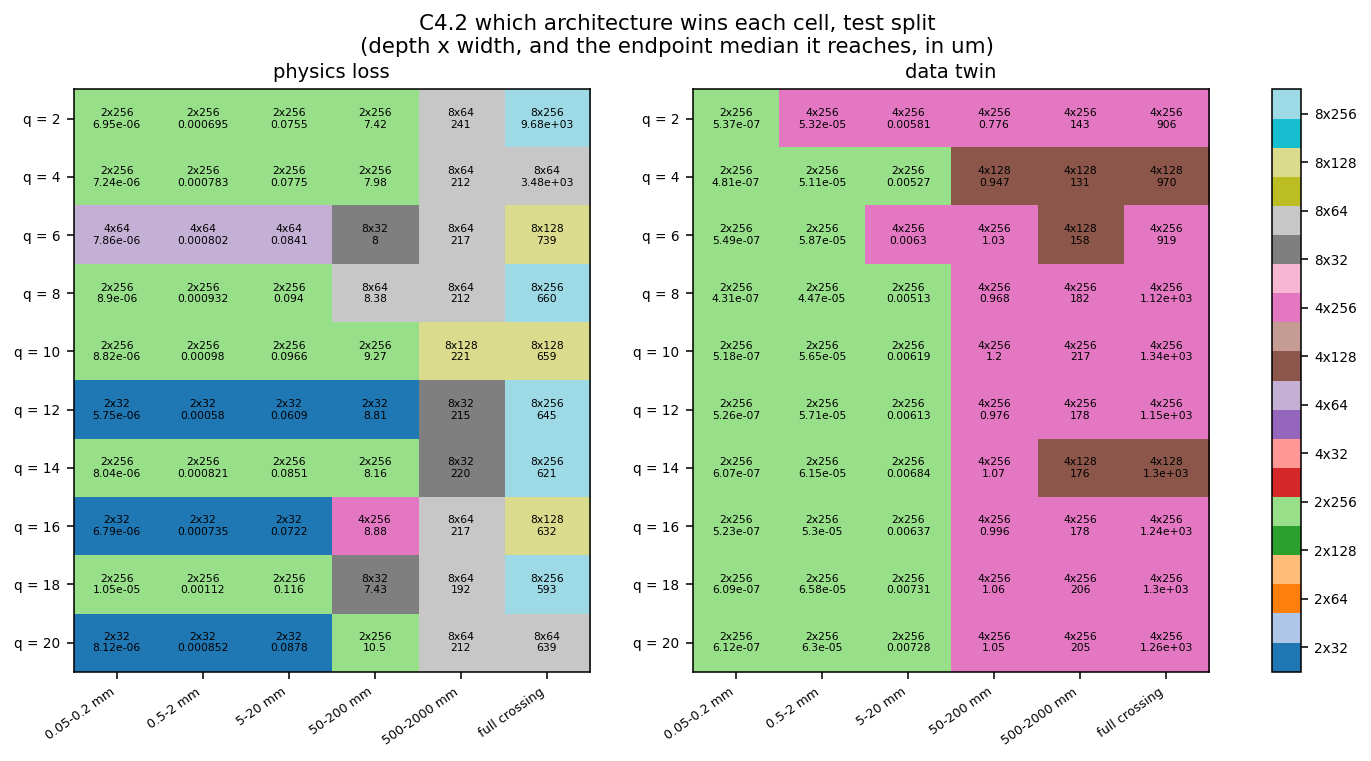

In [6]:
for f in ("heatmap_4x64.png", "heatmap_8x256.png", "error_vs_dz.png",
          "error_vs_q.png", "physics_over_twin.png", "cost_vs_error.png",
          "best_architecture_per_cell.png"):
    print(f)
    display(Image(filename=os.path.join(FIGURES, f)))

## C4.3 (a) In which columns q matters at all

The spread of the cell medians over the ten stage counts, against the spread
over the three seeds inside one cell — the control that says whether a q
dependence is bigger than the optimiser's own noise.

In [7]:
Q = pd.read_csv(os.path.join(RESULTS, "reading_q_sensitivity.csv"))
Q["stratum"] = pd.Categorical(Q["stratum"], STRATA, ordered=True)
display(Q.groupby(["mode", "stratum"], observed=True)
        .agg(spread_over_q=("spread_over_q", "median"),
             seed_spread=("seed_spread_within_cell", "median"),
             archs_where_q_matters=("q_matters", "sum"),
             plateau_from_q=("plateau_from_q", "median")))

spread_over_q  seed_spread  archs_where_q_matters  plateau_from_q
mode    stratum                                                                         
data    0.05-0.2 mm         1.709719     1.431765                      1             2.0
        0.5-2 mm            1.565358     1.351333                      1             2.0
        5-20 mm             1.491005     1.303761                      0             2.0
        50-200 mm           1.459160     1.272140                      0             2.0
        500-2000 mm         1.839463     1.234971                      0             2.0
        full crossing       1.552026     1.332607                      1             2.0
physics 0.05-0.2 mm         2.296575     1.931946                      1             5.0
        0.5-2 mm            2.394708     1.912448                      1             5.0
        5-20 mm             2.386783     1.909335                      1             3.0
        50-200 mm           2.039066     1.724703                      1             2.0
        500-2000 mm         1.252245     1.152913                      0             2.0
        full crossing      13.386256     1.110776                     12             6.0

The full crossing, physics arm: the network sits on the exact scheme at q = 2
and q = 4 and on its own floor from q = 6.

In [8]:
fc = (T[(T.stratum == "full crossing") & (T["mode"] == "physics")]
      .pivot(index="arch", columns="q", values="median_um"))
sch = ref.loc[[2, 4, 6, 8]]["full crossing"]
print("network / exact scheme at the same q:")
print("  q=2 : %.3f - %.3f" % ((fc[2] / sch[2]).min(), (fc[2] / sch[2]).max()))
print("  q=4 : %.3f - %.3f" % ((fc[4] / sch[4]).min(), (fc[4] / sch[4]).max()))
plate = fc[[6, 8, 10, 12, 14, 16, 18, 20]]
print("  q>=6: network %.4g - %.4g um, scheme q=8 %.4g um -> %.0f - %.0f x"
      % (plate.min().min(), plate.max().max(), sch[8],
         plate.min().min() / sch[8], plate.max().max() / sch[8]))
display(fc.style.format("{:.4g}"))

network / exact scheme at the same q:
  q=2 : 1.045 - 1.085
  q=4 : 0.961 - 1.120
  q>=6: network 592.9 - 1745 um, scheme q=8 32.63 um -> 18 - 53 x


q,2,4,6,8,10,12,14,16,18,20
arch,,,,,,,,,,
2x128,9856,3860,968.2,920,868.9,903.5,931.8,847.7,915.2,935.9
2x256,1.005e+04,4050,1101,947.2,997.8,987.9,983,1101,1063,1042
2x32,9831,3817,1582,1424,1563,1676,1414,1608,1558,1745
2x64,9934,3597,1040,996.5,980.1,949.4,1033,1083,1072,1053
4x128,9723,3570,770.3,800.8,721.7,775.7,777.6,729.2,717.7,770.9
4x256,9706,3585,807.5,758.9,814.9,790.6,794.1,779.9,788.3,733.9
4x32,9888,3543,884.9,920.1,867.4,851.7,916.8,910.2,878.9,924.3
4x64,9919,3582,754.6,775.7,736.5,726,813.8,766,769.5,734.9
8x128,9768,3532,739.3,771.2,658.7,677.3,673.2,631.6,673.7,648.3


## (b) How the floor scales with |dz| at fixed q

A log-log fit of the cell median against the stratum's median |dz|, over the
five interior strata. The residual scale goes as |dz|^2, so 2 is the
prediction.

In [9]:
B = pd.read_csv(os.path.join(RESULTS, "reading_dz_slope.csv"))
B["depth"] = B.arch.str.split("x").str[0].astype(int)
display(B.groupby("mode").slope_strata_0_4.describe()[["min", "50%", "max"]])
display(B.pivot_table(index="depth", columns="mode",
                      values="slope_strata_0_4", aggfunc="median"))

,min,50%,max
mode,,,
data,2.032179,2.088301,2.211930
physics,1.707773,1.859350,2.012049


mode,data,physics
depth,,
2,2.117272,1.934331
4,2.073825,1.861475
8,2.077119,1.762155


## (c) The network against the straight line

The cell median divided by the straight line's median on exactly the same rows.

In [10]:
R = pd.read_csv(os.path.join(RESULTS, "reading_ratio_straight.csv"))
R["stratum"] = pd.Categorical(R["stratum"], STRATA, ordered=True)
display(R.pivot_table(index="stratum", columns="mode",
                      values=["ratio_median_over_q", "ratio_best_q"],
                      observed=True).style.format("{:.4g}"))

And the reason the physics arm's short columns are flat in network size while
the twin's are not: the physics loss is normalised by one population-wide input
scale (`_shared/model.reconstruction_residuals` divides by `model.in_scale`),
the twin by the per-sample residual scale (`grid_model.grid_data_loss`).

In [11]:
best_w = (T.groupby(["mode", "stratum", "width"], observed=True)
          .median_um.min().unstack())
display(best_w.style.format("{:.4g}"))

## (d) The label-free loss against supervision, cell by cell

In [12]:
D = pd.read_csv(os.path.join(RESULTS, "reading_physics_vs_twin.csv"))
D["stratum"] = pd.Categorical(D["stratum"], STRATA, ordered=True)
display(D.groupby("stratum", observed=True).physics_over_twin
        .describe()[["min", "25%", "50%", "75%", "max"]])
display(D[D.arch == "8x256"].pivot(index="q", columns="stratum",
                                   values="physics_over_twin")
        .style.format("{:.3g}"))

,min,25%,50%,75%,max
stratum,,,,,
0.05-0.2 mm,1.928077,4.897811,7.807811,11.842168,29.089906
0.5-2 mm,1.917777,5.889021,9.284559,13.718336,32.357489
5-20 mm,1.783109,5.919921,8.323252,12.881936,30.808273
50-200 mm,2.111394,3.405750,5.035412,6.752290,16.336797
500-2000 mm,0.190991,0.351677,0.618832,1.200281,3.404322
full crossing,0.072474,0.115782,0.162667,0.596378,10.715656


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,5.55,6.04,6.29,3.16,0.567,1.94
4,9.52,12,12.1,5.9,0.324,0.611
6,9.83,12.2,10.5,4.69,0.614,0.168
8,7.25,9.04,9.61,4.05,0.267,0.103
10,7.15,8.44,8.41,4.05,0.398,0.143
12,5.69,9.52,8.93,4.8,0.294,0.106
14,7.41,9.54,9.66,6.01,0.558,0.122
16,9.84,13.2,12.8,6.23,0.389,0.112
18,8.3,11.1,13.1,8.41,0.454,0.122


## (e) Which architecture wins each column, and what depth 8 costs

In [13]:
E = pd.read_csv(os.path.join(RESULTS, "reading_best_architecture.csv"))
E["stratum"] = pd.Categorical(E["stratum"], STRATA, ordered=True)
display(E.sort_values(["mode", "stratum"]))
display(T.groupby(["mode", "stratum", "depth"], observed=True)
        .median_um.min().unstack().style.format("{:.4g}"))

,mode,stratum,best_arch,best_q,best_um,best_n_parameters,best_depth2_um,best_depth4_um,best_depth8_um,depth8_over_best,median_over_all_cells_um
6,data,0.05-0.2 mm,2x256,8,4.306528e-07,77092,4.306528e-07,5.404743e-07,0.000002,5.267634,0.000003
7,data,0.5-2 mm,2x256,8,4.471165e-05,77092,4.471165e-05,5.317410e-05,0.000184,4.104457,0.000247
8,data,5-20 mm,2x256,8,5.133316e-03,77092,5.133316e-03,5.805712e-03,0.020415,3.977024,0.025485
9,data,50-200 mm,4x256,2,7.761009e-01,202508,1.038845e+00,7.761009e-01,2.433052,3.134968,3.086954
10,data,500-2000 mm,4x128,4,1.314594e+02,53140,2.578050e+02,1.314594e+02,425.997017,3.240520,564.124967
11,data,full crossing,4x256,2,9.057643e+02,202508,1.457717e+03,9.057643e+02,4170.147581,4.604009,5781.521060
0,physics,0.05-0.2 mm,2x32,12,5.753449e-06,3028,5.753449e-06,7.863314e-06,0.000013,2.185028,0.000015
1,physics,0.5-2 mm,2x32,12,5.797818e-04,3028,5.797818e-04,8.021151e-04,0.001330,2.293925,0.001599
2,physics,5-20 mm,2x32,12,6.091209e-02,3028,6.091209e-02,8.410157e-02,0.141597,2.324615,0.161947
3,physics,50-200 mm,2x256,2,7.418751e+00,70924,7.418751e+00,8.176373e+00,7.431963,1.001781,12.514509


## (f) Forward against backward

C2 found the exact scheme's backward crossings 1.56x worse than its forward
ones at q = 8. The network is asked the same question here.

In [14]:
F = pd.read_csv(os.path.join(RESULTS, "reading_direction.csv"))
F["stratum"] = pd.Categorical(F["stratum"], STRATA, ordered=True)
display(F.groupby(["mode", "stratum"], observed=True)
        .backward_over_forward.median().unstack(0))
sch_dir = S[(S.q == 8) & (S.direction != "both")].pivot(
    index="stratum", columns="direction", values="endpoint_med_um")
sch_dir["backward/forward"] = sch_dir["-1"] / sch_dir["+1"]
display(sch_dir.reindex(STRATA).style.format("{:.4g}"))

mode,data,physics
stratum,,
0.05-0.2 mm,0.966131,1.002906
0.5-2 mm,1.018999,0.952104
5-20 mm,1.036204,0.966290
50-200 mm,0.838210,1.032799
500-2000 mm,0.885815,1.043797
full crossing,1.170617,1.043197


direction,+1,-1,backward/forward
stratum,,,
0.05-0.2 mm,1.421e-11,1.421e-11,1
0.5-2 mm,2.274e-10,2.842e-10,1.25
5-20 mm,3.183e-09,2.899e-09,0.9107
50-200 mm,0.0002202,0.0001779,0.8077
500-2000 mm,0.7589,0.6525,0.8597
full crossing,25.05,39.19,1.565


## (g) The tails

In [15]:
G = pd.read_csv(os.path.join(RESULTS, "reading_p95.csv"))
G["stratum"] = pd.Categorical(G["stratum"], STRATA, ordered=True)
display(G.groupby(["mode", "stratum"], observed=True)
        .agg(p95_over_median=("p95_over_median", "median"),
             p95_over_straight_p95=("p95_over_straight_p95", "median")))

p95_over_median  p95_over_straight_p95
mode    stratum                                              
data    0.05-0.2 mm          20.806864               0.047483
        0.5-2 mm             22.854828               0.047905
        5-20 mm              20.122316               0.045488
        50-200 mm            18.189029               0.047407
        500-2000 mm          13.042341               0.068603
        full crossing        12.928061               0.050447
physics 0.05-0.2 mm           8.645346               0.141956
        0.5-2 mm              8.604342               0.146519
        5-20 mm               8.204016               0.144088
        50-200 mm             7.153551               0.084015
        500-2000 mm          10.170020               0.030562
        full crossing        11.061187               0.007593

## (h) Cost: error per parameter, and the cost-error front

In [16]:
H = pd.read_csv(os.path.join(RESULTS, "reading_cost.csv"))
for st in ("50-200 mm", "full crossing"):
    for mode in ("physics", "data"):
        s = H[(H.stratum == st) & (H["mode"] == mode)].sort_values("n_parameters")
        best, front = np.inf, []
        for _, r in s.iterrows():
            if r.median_um < best:
                best = r.median_um
                front.append(r)
        print("=" * 20, st, mode, "- cost-error front")
        display(pd.DataFrame(front)[["arch", "q", "n_parameters",
                                     "multiply_adds", "median_um",
                                     "gain_over_straight"]]
                .reset_index(drop=True))
        print("best gain per thousand parameters:")
        display(s.nlargest(3, "gain_per_kparam")[
            ["arch", "q", "n_parameters", "median_um", "gain_over_straight",
             "gain_per_kparam"]])

==================== 50-200 mm physics - cost-error front


,arch,q,n_parameters,multiply_adds,median_um,gain_over_straight
0,2x32,2,1708,1632,33.737631,4.180812
1,2x32,4,1972,1888,14.281508,9.876457
2,2x32,8,2500,2400,12.532548,11.254751
3,2x32,10,2764,2656,11.754380,11.999842
4,2x32,12,3028,2912,8.807257,16.015283
5,4x32,14,5404,5216,8.701870,16.209240
6,8x32,2,8044,7776,7.899141,17.856461
7,8x32,18,10156,9824,7.431963,18.978931
8,2x256,2,70924,70400,7.418751,19.012729


best gain per thousand parameters:


,arch,q,n_parameters,median_um,gain_over_straight,gain_per_kparam
388,2x32,12,3028,8.807257,16.015283,5.289063
360,2x32,4,1972,14.281508,9.876457,5.008346
374,2x32,8,2500,12.532548,11.254751,4.501901


==================== 50-200 mm data - cost-error front


...

,arch,q,n_parameters,median_um,gain_over_straight,gain_per_kparam
370,2x32,6,2236,1581.579243,288.366945,128.965539
377,2x32,8,2500,1423.917987,320.295957,128.118383
930,4x32,6,4348,884.864850,515.417891,118.541373


==================== full crossing data - cost-error front


,arch,q,n_parameters,multiply_adds,median_um,gain_over_straight
0,2x32,2,1708,1632,8623.407479,52.888046
1,4x32,2,3820,3680,7655.535961,59.574558
2,4x32,4,4084,3936,5952.567484,76.618228
3,4x64,2,13772,13504,3565.464417,127.914662
4,2x128,2,19084,18816,3464.235673,131.652468
5,2x128,4,20116,19840,3317.951643,137.456848
6,4x128,2,52108,51584,1387.250671,328.761906
7,4x128,4,53140,52608,969.965592,470.197271
8,4x256,2,202508,201472,905.764338,503.525205


best gain per thousand parameters:


,arch,q,n_parameters,median_um,gain_over_straight,gain_per_kparam
286,2x32,2,1708,8623.407479,52.888046,30.964898
293,2x32,4,1972,9679.959920,47.115399,23.892190
300,2x32,6,2236,9627.264647,47.373287,21.186622
